<hr/>
<b>Nombre</b>: Jesus David Serpa Pajaro


## Enunciado

**Objetivo**: El objetivo de esta tarea es comparar los distintos modelos de atmósferas vistos en el curso, frente al modelo de atmósfera empírica [NRLMSISE-00](https://en.wikipedia.org/wiki/NRLMSISE-00) (_US Naval Research Laboratory mass spectrometer and incoherent scatter radar_). Este modelo puede darnos información de la atmósfera en distintas ubicaciones en la Tierra, épocas del año, horas del día e incluso épocas del ciclo solar.

**Procedimiento**:

Para conseguir el objetivo:

1. Obtener los datos de la atmósfera desde la superficie hasta 100 km en una ubicación, fecha y hora específica cada 50 metros.  Para ello puede usar el día y lugar de nacimiento. Asuma para la hora de nacimiento las 12 m (medio día). Para la ubicación use la ciudad del mundo que siempre ha soñado visitar o que más ha disfrutado visitar.

2. Usando los datos de composición de la atmósfera, calcule la presión atmosférica a cada altura. Asuma para ello la ecuación de estado de gas ideal.  Haga gráficos de temperatura, densidad y presión con la altura, usando la convención en ciencias atmosféricas de poner la altura en el eje y.

3. Evalúe si en la atmósfera calculada hay equilibrio hidrostático, es decir, si se cumple a cada altura la condición:

  $$
\frac{dp}{dz} = -\rho(z) g(z)
$$
   Use valores de la aceleración de la gravedad que varíen con la altura.

3. Llamamos tropopausa a la altura en la atmósfera en la que la temperatura deja de disminuir con la altura. Encuentre la altura de la **tropopausa** para el sitio y lugar elegido. A la capa de la atmósfera debajo de esa altura se la llama la **troposfera**.

4. Haga un gráfico de contornos sobre un mapa (use el código de ejemplo mostrado al final del enunciado) en el que muestre la altura de la troposfera como función de la longitud y la latitud. Observe. Haga una animación mostrando la temperatura en la superficie de la Tierra a lo largo de 1 día.

5. Vamos a determinar los mejores parámetros de un modelo homentrópico que ajustan las curvas de presión, densidad y temperatura para la troposfera de la atmósfera real (en el sitio y fecha que eligio en 1). Nuestros parámetros libres serán: $h_0$, $\gamma$ y temperatura superficial $T_0$.  Asuma valores para estas tres cantidades como los que usamos en ejemplos en clase y calcule el valor del estadístico $\chi^2$:

 $$
 \chi^2(h_0, \gamma, T_0) = \sum_i\frac{[T_\text{hom}(z_i)-T(z_i)]^2}{T(z_i)^2} + \sum_i\frac{[\rho_\text{hom}(z_i)-\rho(z_i)]^2}{\rho(z_i)^2}+ \sum_i\frac{[p_\text{hom}(z_i)-p(z_i)]^2}{p(z_i)^2}
 $$

 Ahora minimize el valor de $\chi^2$ con respecto a los parámetros $h_0, \gamma, T_0$ para encontrar el modelo homentrópico que mejor se adapta a los perfiles de temperatura, densidad y presión de la tropósfera.

 **Ayuda**: Use la rutina `scipy.optimize.minimize`

6. Repita el procedimiento anterior para muchos puntos en la superficie de la Tierra y haga mapas de $h_0$, $\gamma$ y $T_0$ sobre la superficie del planeta. Comente los resultados que obtiene.

## ¿Cómo hacer mapas con `cartopy`

El paquete `cartopy` es el _standard de facto_ para hacer mapas con `matplotlib`. Aquí encuentra la documentación: https://scitools.org.uk/cartopy/docs/v0.5/index.html.

In [ ]:
!pip install -Uq cartopy

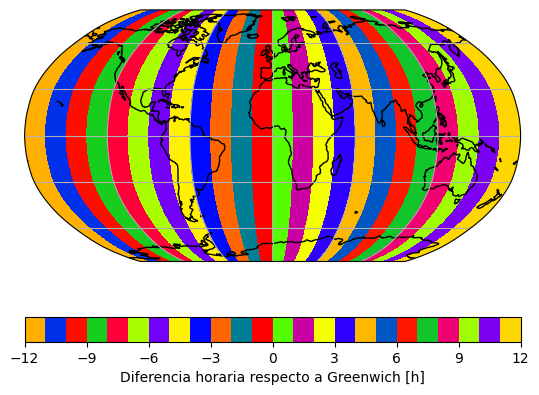

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()
ax.coastlines()
ax.gridlines()

lats = np.linspace(-90, 90, 10)
lons = np.linspace(-180, 180, 10)
LONS,LATS = np.meshgrid(lons,lats)
data = LONS/15

plt.contourf(LONS, LATS, data, transform=ccrs.PlateCarree(),levels=24,cmap='prism')
cbar = plt.colorbar(orientation='horizontal')
cbar.set_label('Diferencia horaria respecto a Greenwich [h]')

## Solución

Intalamos lo necesarion

In [ ]:
!pip install -q nrlmsise00
!pip install -qU 'nrlmsise00[dataset]'
!pip install -q spaceweather
!pip install -Uq mendeleev
!pip install -q celluloid

Importamos la librerias a usar

In [ ]:
import numpy as np
import pandas as pd
import warnings
import spaceweather as sw
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import scipy.interpolate as interpolate



from celluloid import Camera
from mendeleev import element
from datetime import datetime
from IPython.display import HTML
from scipy import constants as c
from scipy.optimize import minimize
from nrlmsise00.dataset import msise_4d

sw.update_data()

Definimos constantes

In [ ]:
atm =101.325e3 #
R = c.R #pa m^3 / mol K
C = 273.15 # K
g0 = 9.8 # m/s^2
RT = 6371e3 # m radio tierra

1. Obtener los datos de la atmósfera desde la superficie hasta 100 km en una ubicación, fecha y hora específica cada 50 metros.  Para ello puede usar el día y lugar de nacimiento. Asuma para la hora de nacimiento las 12 m (medio día). Para la ubicación use la ciudad del mundo que siempre ha soñado visitar o que más ha disfrutado visitar.



Hacemos la lista de altura y sacamos los datos

In [ ]:
hmax=100e3 # m
zs=np.arange(0,hmax,50) # m

ds = msise_4d(datetime(1999,12,24,12,0,0),zs/1e3,[53],[13])

2. Usando los datos de composición de la atmósfera, calcule la presión atmosférica a cada altura. Asuma para ello la ecuación de estado de gas ideal.  Haga gráficos de temperatura, densidad y presión con la altura, usando la convención en ciencias atmosféricas de poner la altura en el eje y.


Sacamos la densidad y la temperatura

In [ ]:
ρs=np.array(ds["rho"]).flatten()
Ts=np.array(ds["Talt"]).flatten()


Asumimos gas ideal:

$$
\frac{p}{\rho} = \frac{RT}{M_\text{mol}}
$$


Primeramente calculamos el Mmol de la atmosfera

In [ ]:
species = [
    dict(name='N2',Mmol=2*element('Nitrogen').atomic_weight),
    dict(name='O2',Mmol=2*element('Oxygen').atomic_weight),
    dict(name='Ar',Mmol=1*element('Argon').atomic_weight),
    dict(name='N',Mmol=1*element('Nitrogen').atomic_weight),
    dict(name='O',Mmol=1*element('Oxygen').atomic_weight),
    dict(name='H',Mmol=1*element('Hydrogen').atomic_weight),
]
ns = np.zeros(len(species))
ms = np.zeros(len(species))
for i,specie in enumerate(species):
  ns[i] = np.array(ds[specie['name']]).flatten()[0]
  ms[i] = specie['Mmol']*ns[i]
n = ns.sum()
Mmol = ms.sum()/n
Mmol

28.96034151792078

Calculamos la presion

In [ ]:
ps = c.R*ρs*1e3*Ts/(Mmol*1e-3)

Graficamos

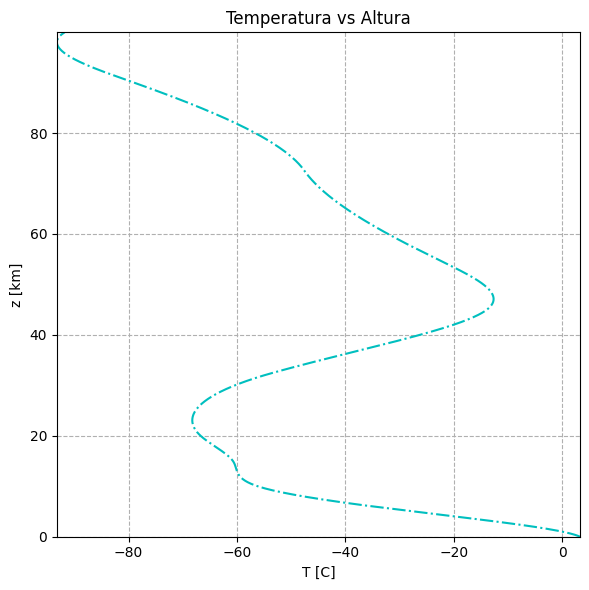

In [ ]:
fig,ax=plt.subplots(figsize=(6,6))

#Temperatura
ax.plot(Ts-C,zs/1e3,'c-.',label='Temperatura')

#Decoración
ax.set_xlabel("T [C]")
ax.set_ylabel("z [km]")
ax.margins(0,0)
ax.set_title('Temperatura vs Altura')
ax.grid(True, which="both", ls="--")
fig.tight_layout()

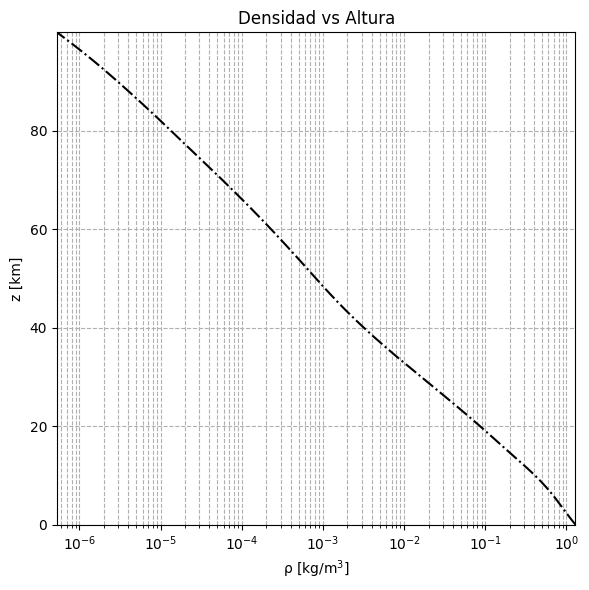

In [ ]:
fig,ax=plt.subplots(figsize=(6,6))

ax.plot(ρs*1e3,zs/1e3,'k-.',label='Densidad')

#Decoración
ax.set_xlabel("ρ [kg/m$^3$]")
ax.set_ylabel("z [km]")
ax.margins(0,0)
ax.set_xscale('log')
ax.set_title('Densidad vs Altura')
ax.grid(True, which="both", ls="--")
fig.tight_layout()

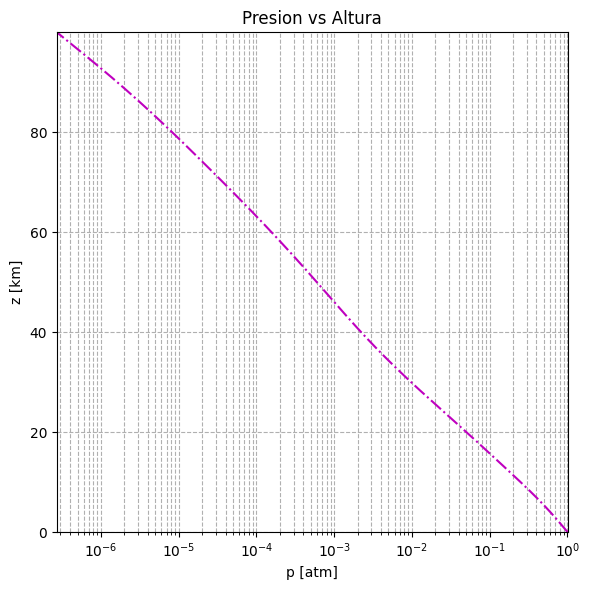

In [ ]:
fig,ax=plt.subplots(figsize=(6,6))

ax.plot(ps/atm,zs/1e3,'m-.')

#Decoración
ax.set_xlabel("p [atm]")
ax.set_ylabel("z [km]")
ax.margins(0,0)
ax.set_xscale('log')
ax.set_title('Presion vs Altura')
ax.grid(True, which="both", ls="--")
fig.tight_layout()


3. Evalúe si en la atmósfera calculada hay equilibrio hidrostático, es decir, si se cumple a cada altura la condición:

  $$
\frac{dp}{dz} = -\rho(z) g(z)
$$
   Use valores de la aceleración de la gravedad que varíen con la altura.


In [ ]:
ΔPΔz = np.zeros_like(zs)

for i in range(len(ps)-1):
  ΔP = ps[i] - ps[i+1]
  Δz = zs[i] - zs[i+1]
  ΔPΔz[i] = ΔP/Δz

In [ ]:
ΔPΔz


array([-1.26046239e+01, -1.25314817e+01, -1.24590495e+01, ...,
       -5.02938698e-06, -4.98167078e-06,  0.00000000e+00])

Para el calculo de la gravidad variable.Si tomamos como referencia la gravedad superficial:
$$
g(z) = g_0 \frac{R^2}{(R+z)^2} = \frac{g_0}{(1+z/R)^2}
$$

In [ ]:
gz = lambda z:g0/(1+z/RT)**2

gs = gz(zs)


In [ ]:
ρgs = -gs*ρs *atm
ρgs

array([-1.27954463e+03, -1.27210496e+03, -1.26473781e+03, ...,
       -5.17154008e-04, -5.12287020e-04, -5.07461958e-04])

In [ ]:
eqH = pd.DataFrame()
eqH['Altura'] = zs
eqH['ΔPΔz ']= ΔPΔz


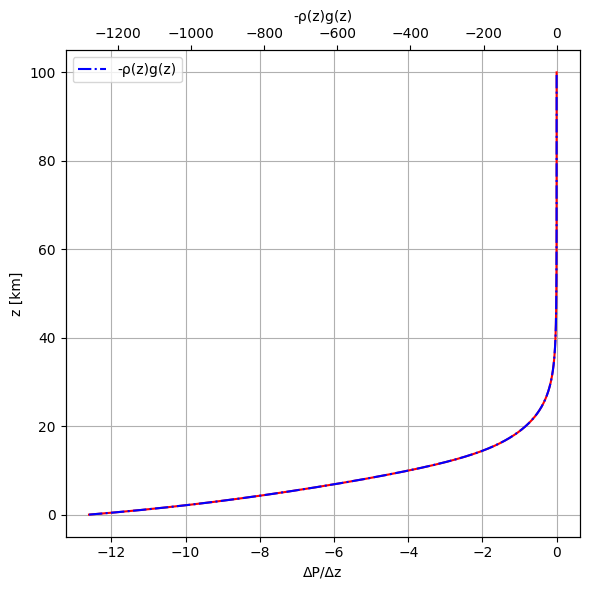

In [ ]:
fig,ax=plt.subplots(figsize=(6,6))

# ΔPΔz
ax.plot(ΔPΔz,zs/1e3,'r',label= 'ΔP/Δz')

# -ρ(z)g(z)
axd=ax.twiny()
axd.plot(ρgs,zs/1e3,'b-.', label = '-ρ(z)g(z)')

#Decoración
axd.legend()
ax.set_ylabel("z [km]")
ax.set_xlabel("ΔP/Δz")
axd.set_xlabel("-ρ(z)g(z)")
ax.grid(True)
fig.tight_layout()

plt.legend()

. Llamamos tropopausa a la altura en la atmósfera en la que la temperatura deja de disminuir con la altura. Encuentre la altura de la **tropopausa** para el sitio y lugar elegido. A la capa de la atmósfera debajo de esa altura se la llama la **troposfera**.

In [ ]:
min=[]
for i in range(1, len(Ts)-1):
    if Ts[i] < Ts[i-1] and Ts[i] < Ts[i+1]:
     min.append(zs[i])
htrop = min[0]
print('Altura de la tropopausa =',htrop,'km')

Altura de la tropopausa = 23050.0 km


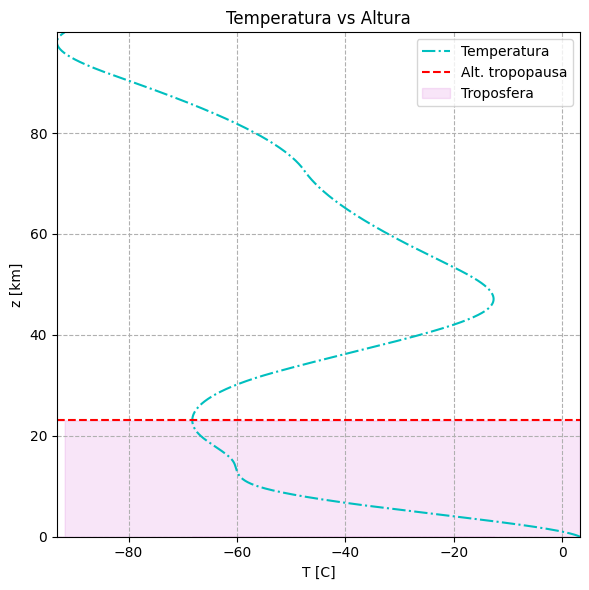

In [ ]:
fig,ax=plt.subplots(figsize=(6,6))

#Temperatura
ax.plot(Ts-C,zs/1e3,'c-.',label='Temperatura')
ax.axhline(y=min[0]/1e3, color='r', linestyle='--', label='Alt. tropopausa')

upper_th = min[0]/1e3
lower_th = 0
ax.fill_between(x=Ts-C, y1=upper_th, y2=lower_th, color='m' \
  , label='Troposfera', alpha=.1)

#Decoración
ax.set_xlabel("T [C]")
ax.set_ylabel("z [km]")
ax.margins(0,0)
ax.set_title('Temperatura vs Altura')
ax.grid(True, which="both", ls="--")
plt.legend()
fig.tight_layout()

sacamos datos hasta la troposfera

In [ ]:
Ttrop = Ts[0:462]
ρtrop = ρs[0:462]
ptrop = ps[0:462]

5. Haga un gráfico de contornos sobre un mapa (use el código de ejemplo mostrado al final del enunciado) en el que muestre la altura de la troposfera como función de la longitud y la latitud. Observe. Haga una animación mostrando la temperatura en la superficie de la Tierra a lo largo de 1 día.


In [ ]:
lats = np.linspace(-90, 90, 10)
lons = np.linspace(-180, 180, 10)

data = []
for lat in lats:
  latxlog = []
  for lon in lons:
    dss = msise_4d(datetime(1999,12,24,12,0,0),zs/1e3,[lat],[lon])
    Tt=np.array(dss["Talt"]).flatten()

    minn=[]
    for i in range(1, len(Ts)-1):
      if Tt[i] < Tt[i-1] and Tt[i] < Tt[i+1]:
        minn.append(zs[i])

    latxlog.append(minn[0])
  data.append(latxlog)


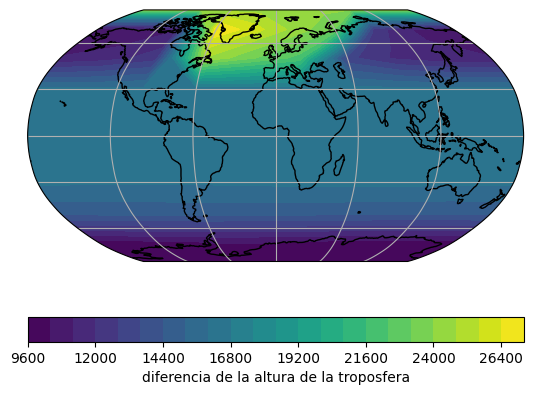

In [ ]:
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()
ax.coastlines()
ax.gridlines()

lats = np.linspace(-90, 90, 10)
lons = np.linspace(-180, 180, 10)
LONS,LATS = np.meshgrid(lons,lats)

#data = LONS/15

plt.contourf(LONS, LATS, data, transform=ccrs.PlateCarree() \
             ,levels=24,cmap='viridis')
cbar = plt.colorbar(orientation='horizontal')
cbar.set_label('diferencia de la altura de la troposfera')

In [ ]:
ts = pd.date_range(start=datetime(1999, 12, 24, 0, 0, 0),\
                   end=datetime(1999, 12, 25, 0, 0, 0), freq='5H')

Tp = []
for t in ts:
    dss = [msise_4d(t, 0, [lat], [lon]) for lat, lon in zip(lats, lons)]
    tss = np.array([ds["Talt"] for ds in dss]).flatten()
    Tp.append(tss)

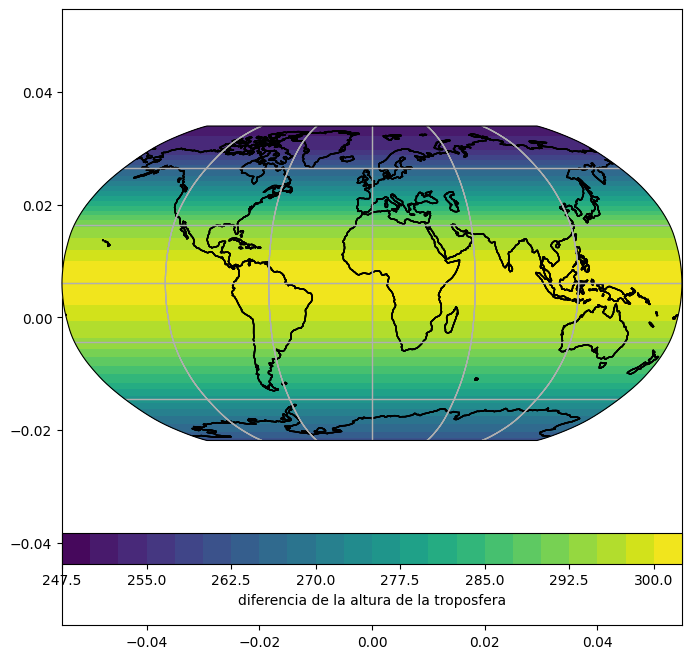

In [ ]:
fig = plt.figure(figsize = (8,8))

c = Camera(fig)
plt.axis("equal")

ax = plt.axes(projection=ccrs.Robinson())

for Tem  in Tp:

  ax.set_global()
  ax.coastlines()
  ax.gridlines()

  lats = np.linspace(-90, 90, 10)
  lons = np.linspace(-180, 180, 10)
  LONS,LATS = np.meshgrid(lons,lats)
  TT = np.tile(Tem, (len(lats), 1)).T
  plt.contourf(LONS, LATS, TT, transform=ccrs.PlateCarree() \
               ,levels=24,cmap='viridis')
  c.snap()

cbar = plt.colorbar(orientation='horizontal')
cbar.set_label('diferencia de la altura de la troposfera')

In [ ]:
anim = c.animate()
HTML(anim.to_html5_video())

6. Vamos a determinar los mejores parámetros de un modelo homentrópico que ajustan las curvas de presión, densidad y temperatura para la troposfera de la atmósfera real (en el sitio y fecha que eligio en 1). Nuestros parámetros libres serán: $h_0$, $\gamma$ y temperatura superficial $T_0$.  Asuma valores para estas tres cantidades como los que usamos en ejemplos en clase y calcule el valor del estadístico $\chi^2$:

 $$
 \chi^2(h_0, \gamma, T_0) = \sum_i\frac{[T_\text{hom}(z_i)-T(z_i)]^2}{T(z_i)^2} + \sum_i\frac{[\rho_\text{hom}(z_i)-\rho(z_i)]^2}{\rho(z_i)^2}+ \sum_i\frac{[p_\text{hom}(z_i)-p(z_i)]^2}{p(z_i)^2}
 $$
 Ahora minimize el valor de $\chi^2$ con respecto a los parámetros $h_0, \gamma, T_0$ para encontrar el modelo homentrópico que mejor se adapta a los perfiles de temperatura, densidad y presión de la tropósfera.

 **Ayuda**: Use la rutina `scipy.optimize.minimize`

In [ ]:
warnings.filterwarnings('ignore')

In [ ]:
def Χ2(params,emp):
    ho, γ, To = params
    Temp, ρemp, pemp = emp

    h2 = γ / (γ - 1)*ho

    Ts_hom = To * (1 - (zs/h2))
    ρs_hom = ρo * (1 -( zs/h2))**(1 / (γ - 1))
    ps_hom = po * (1 - (zs/h2))**(γ / (γ - 1))

    Χ = 0
    for i in range(len(zs)):
      suma = (((Ts_hom[i] - Temp[i])**2 / Temp[i]**2) +
            ((ρs_hom[i] - ρemp[i])**2 / ρemp[i]**2) +
            ((ps_hom[i] - pemp[i])**2 / pemp[i]**2))
      Χ += suma
    return Χ

In [ ]:
Ts

array([276.39958234, 276.298197  , 276.18983877, ..., 181.21442472,
       181.2874549 , 181.36271578])

In [ ]:
po=1*atm
ρo=1.225 # kg/m^3
go=9.80665 # m/s^2
γo= 7/5
To=15+273.15 #K
ho=po/(ρo*go)
zs = np.arange(0,htrop+1,50)

emp = [Ts, ρs, ps]
params = [ho, γo, To]
value = minimize(Χ2, params, args=(emp,), method='TNC')

In [ ]:
hopt, γopt, Topt = value.x
hopt=hopt.copy()
hopt, γopt, Topt

(8434.509818774577, 1.4, 288.15)

In [ ]:
h2opt = hopt / (γopt - 1)
Ts_hom=Topt*(1-((zs/1e3)/h2opt))
ρs_hom=ρo*(1-zs/h2opt)**(1/(γopt-1))
ps_hom=po*(1-zs/h2opt)**(γopt/(γopt-1))

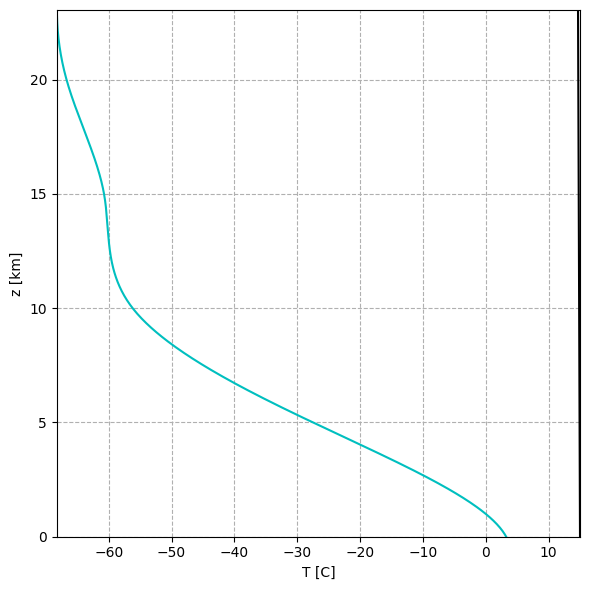

In [ ]:
fig,ax=plt.subplots(figsize=(6,6))

#Presión
ax.plot(Ttrop-273.15,zs/1e3,'c-',label='Mod. empírico')

#Densidad
axd=ax.twiny()
axd.plot(Ts_hom-273.15,zs/1e3,'k',label='Mod. Homentropico')

#Decoración
axd.legend()
ax.set_xlabel("T [C]")
ax.set_ylabel("z [km]")
ax.margins(0,0)
ax.grid(True, which="both", ls="--")

fig.tight_layout()

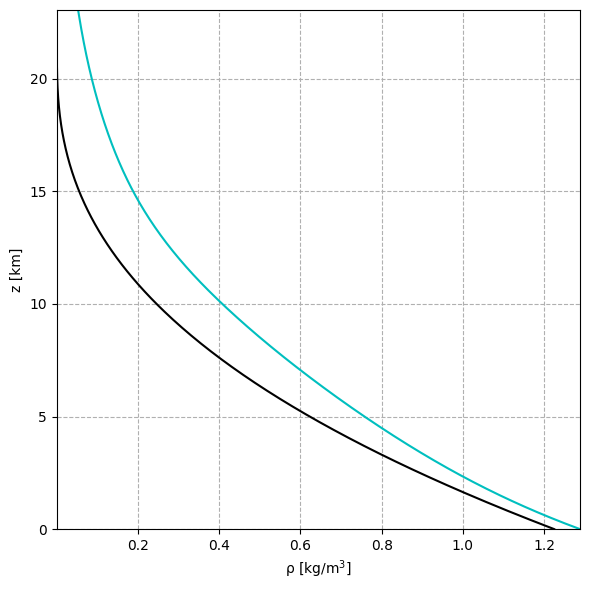

In [ ]:

fig,ax=plt.subplots(figsize=(6,6))

#Presión
plt.plot(ρtrop*1e3,zs/1e3,'c-',label='Mod. empírico')

#Densidad
plt.plot(ρs_hom,zs/1e3,'k',label='Mod. Homentropico')

#Decoración
axd.legend()
ax.set_xlabel("ρ [kg/m$^3$]")
ax.set_ylabel("z [km]")
ax.margins(0,0)
ax.grid(True, which="both", ls="--")

fig.tight_layout()

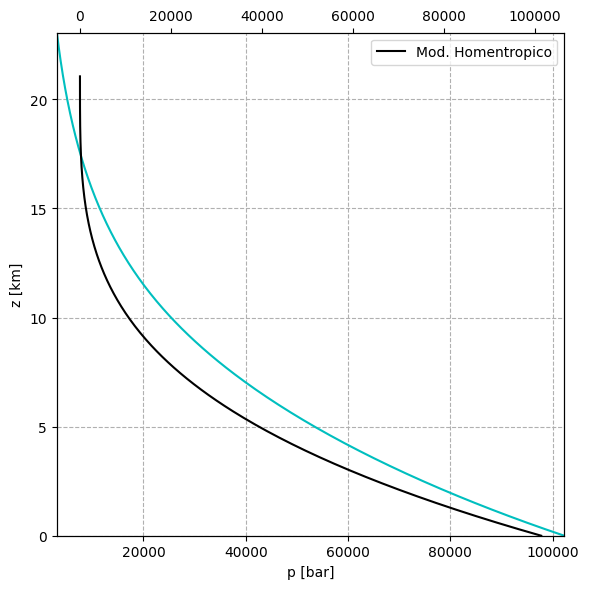

In [ ]:
fig,ax=plt.subplots(figsize=(6,6))

#Presión
ax.plot(ptrop,zs/1e3,'c-',label='Mod. empírico')

#Densidad
axd=ax.twiny()
axd.plot(ps_hom,zs/1e3,'k',label='Mod. Homentropico')

#Decoración
axd.legend()
ax.set_xlabel("p [bar]")
ax.set_ylabel("z [km]")
ax.margins(0,0)
ax.grid(True, which="both", ls="--")

fig.tight_layout()

7. Repita el procedimiento anterior para muchos puntos en la superficie de la Tierra y haga mapas de $h_0$, $\gamma$ y $T_0$ sobre la superficie del planeta. Comente los resultados que obtiene.

In [ ]:
lats = np.linspace(-90, 90, 10)
lons = np.linspace(-180, 180, 10)

Temp_ = []
ρemp_ = []
pemp_ = []

for lat in lats:
  Tlatlog = []
  ρlatlog = []
  platlog = []

  for lon in lons:
    dss = msise_4d(datetime(1999,12,24,12,0,0),zs/1e3,[lat],[lon])
    Tt=np.array(dss["Talt"]).flatten()
    ρρ=np.array(ds["rho"]).flatten()

    ns = np.zeros(len(species))
    ms = np.zeros(len(species))
    for i,specie in enumerate(species):
      ns[i] = np.array(ds[specie['name']]).flatten()[0]
      ms[i] = specie['Mmol']*ns[i]
    n = ns.sum()
    Mmol = ms.sum()/n
    Mmol
    pp = R*ρs*1e3*Ts/(Mmol*1e-3)

    Tlatlog.append(Tt)
    ρlatlog.append(ρρ)
    platlog.append(pp)

  Temp_.append(np.array(Tlatlog))
  ρemp_.append(np.array(ρlatlog))
  pemp_.append(np.array(platlog))



In [ ]:
po=1*atm
ρo=1.225 # kg/m^3
go=9.80665 # m/s^2
γo= 7/5
To=15+273.15 #K
ho=po/(ρo*go)

calculamos los parametros

In [ ]:
hemp = []
γemp = []
Temp = []

for i in range(len(lats)):
  x = []
  y = []
  z = []
  for j in range(len(lons)):
    empp = [Temp_[i][j], ρemp_[i][j]*1e3, pemp_[i][j]]
    params = [ho, γo, To]
    value = minimize(Χ2, params, args=(empp,), method='TNC')
    hopt, γopt, Topt = value.x

    x.append(hopt)
    y.append(γopt)
    z.append(Topt-273.5)
  hemp.append(x)
  γemp.append(y)
  Temp.append(z)

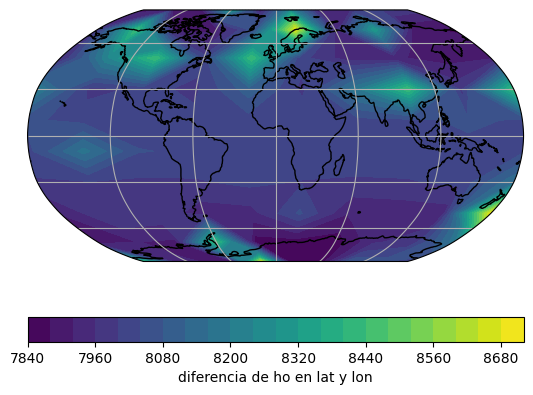

In [ ]:
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()
ax.coastlines()
ax.gridlines()

lats = np.linspace(-90, 90, 10)
lons = np.linspace(-180, 180, 10)
LONS,LATS = np.meshgrid(lons,lats)

#data = LONS/15

plt.contourf(LONS, LATS, hemp, transform=ccrs.PlateCarree() \
             ,levels=24,cmap='viridis')
cbar = plt.colorbar(orientation='horizontal')
cbar.set_label('diferencia de ho en lat y lon')

A partir de la grafica podemos apreciar el cambio de $h0$, y vamos que la altura es muy alta en ciertos puntos de los polos o en latitudes muy altas a diferencia del nivel del mar.

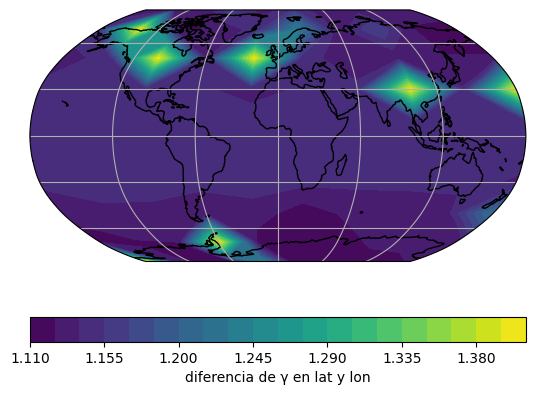

In [ ]:
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()
ax.coastlines()
ax.gridlines()

lats = np.linspace(-90, 90, 10)
lons = np.linspace(-180, 180, 10)
LONS,LATS = np.meshgrid(lons,lats)

#data = LONS/15

plt.contourf(LONS, LATS, γemp, transform=ccrs.PlateCarree() \
             ,levels=24,cmap='viridis')
cbar = plt.colorbar(orientation='horizontal')
cbar.set_label('diferencia de γ en lat y lon')

A partir del $γ$ en difentes latitudes y longitudes podemos ver que es realtivamente contanste en la mayor parte del planeta a diferencia de ciertos puntos.

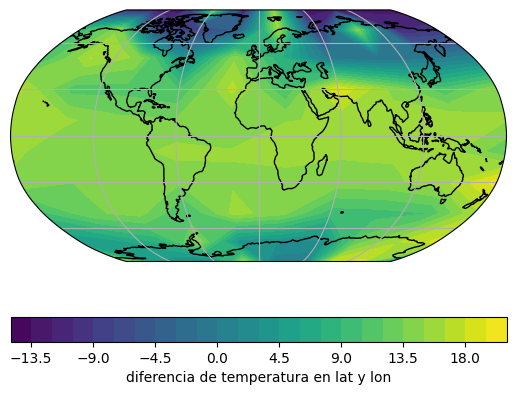

In [ ]:
ax = plt.axes(projection=ccrs.Robinson())
ax.set_global()
ax.coastlines()
ax.gridlines()

lats = np.linspace(-90, 90, 10)
lons = np.linspace(-180, 180, 10)
LONS,LATS = np.meshgrid(lons,lats)

#data = LONS/15

plt.contourf(LONS, LATS, Temp, transform=ccrs.PlateCarree() \
             ,levels=24,cmap='viridis')
cbar = plt.colorbar(orientation='horizontal')
cbar.set_label('diferencia de temperatura en lat y lon')

podemos ver que la temperatura es mucho mayor a nivel del mar a comparacion de los polos del planteta.